# SMM636 Machine Learning - Coursework 02

**Individual Project: Predictive modelling of coronary heart disease (CHD)**

Full report available via: [GitHub Pages](https://ytterbiu.github.io/SMM636-ML-a02-heart-disease/)

Formatter: black

This notebook depends on external Python packages. Before running, install the required dependencies:

```bash
pip install -r requirements.txt
```


## 0. Imports / Setup


In [ ]:
# ============================================================================ #
# Key Information ====
# SMM636 Machine Learning
# Individual Coursework 2025-26
# Author:       Benjamin Evans
# Professor:    Dr. Rui Zhu
# Institution:  Bayes Business School - City St George's, University of London
# Date:         27 Mar 2026
#
# Description:  Term 2 individual project for SMM636 Machine Learning
#               (50% of coursework grade - 50% of module grade).
# ============================================================================ #


In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

plt.rcParams['text.antialiased'] = True
plt.rcParams['font.family'] = 'sans-serif'

In [ ]:
# sklearn
from sklearn.model_selection import (
    train_test_split,
    GridSearchCV,
    StratifiedKFold,
    cross_val_score,
    cross_val_predict,
)
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.svm import SVC
from sklearn.decomposition import PCA, FactorAnalysis
from sklearn.manifold import MDS
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    roc_auc_score,
    roc_curve,
    ConfusionMatrixDisplay,
    f1_score,
)
from sklearn.pipeline import Pipeline
from sklearn.calibration import CalibrationDisplay
from sklearn.inspection import permutation_importance
from sklearn.model_selection import learning_curve
from statsmodels.stats.contingency_tables import mcnemar

import shap
import warnings

warnings.filterwarnings("ignore")

In [ ]:
# Reproducibility
SEED = 42
np.random.seed(SEED)

In [ ]:
# figure saving utilities
FIG_DIR = "fig/"
import os

os.makedirs(FIG_DIR, exist_ok=True)


def savefig(name, **kwargs):
    """Save current figure to fig/ directory."""
    plt.savefig(f"{FIG_DIR}{name}.png", dpi=250, bbox_inches="tight", **kwargs)
    plt.savefig(f"{FIG_DIR}{name}.pdf", bbox_inches="tight", **kwargs)

## 1. Exploratory analysis


### Data loading

In [ ]:
# Load data
df = pd.read_csv("data/heart-disease.csv")

print(f"Dataset: {df.shape[0]} observations, {df.shape[1]} variables")
print(f"Missing values: {df.isnull().sum().sum()}")
df.head()

Dataset: 462 observations, 10 variables
Missing values: 0


,sbp,tobacco,ldl,adiposity,famhist,typea,obesity,alcohol,age,chd
0,160,12.00,5.73,23.11,Present,49,25.30,97.20,52,1
1,144,0.01,4.41,28.61,Absent,55,28.87,2.06,63,1
2,118,0.08,3.48,32.28,Present,52,29.14,3.81,46,0
3,170,7.50,6.41,38.03,Present,51,31.99,24.26,58,1
4,134,13.60,3.50,27.78,Present,60,25.99,57.34,49,1


### Descriptive stats

In [ ]:
# Descriptive statistics
df.describe().round(2)

,sbp,tobacco,ldl,adiposity,typea,obesity,alcohol,age,chd
count,462.00,462.00,462.00,462.00,462.00,462.00,462.00,462.00,462.00
mean,138.33,3.64,4.74,25.41,53.10,26.04,17.04,42.82,0.35
std,20.50,4.59,2.07,7.78,9.82,4.21,24.48,14.61,0.48
min,101.00,0.00,0.98,6.74,13.00,14.70,0.00,15.00,0.00
25%,124.00,0.05,3.28,19.77,47.00,22.98,0.51,31.00,0.00
50%,134.00,2.00,4.34,26.12,53.00,25.80,7.51,45.00,0.00
75%,148.00,5.50,5.79,31.23,60.00,28.50,23.89,55.00,1.00
max,218.00,31.20,15.33,42.49,78.00,46.58,147.19,64.00,1.00


In [ ]:
# Class balance
print("Target distribution:")
print(df["chd"].value_counts(),end="\n\n")
print(f"CHD prevalence: {df['chd'].mean():.1%}")
print(f"Baseline accuracy (always predict majority): {1 - df['chd'].mean():.1%}")

Target distribution:
chd
0    302
1    160
Name: count, dtype: int64

CHD prevalence: 34.6%
Baseline accuracy (always predict majority): 65.4%


302 healthy controls versus 160 CHD positive cases gives a 65:35 split. A classifier that always predicts "no CHD" achieves 65.4% accuracy, so any useful model must exceed this baseline. 

The imbalance is moderate rather than severe, and its practical impact depends on the number of features (addressed below with the Zhu et al. adjustment).

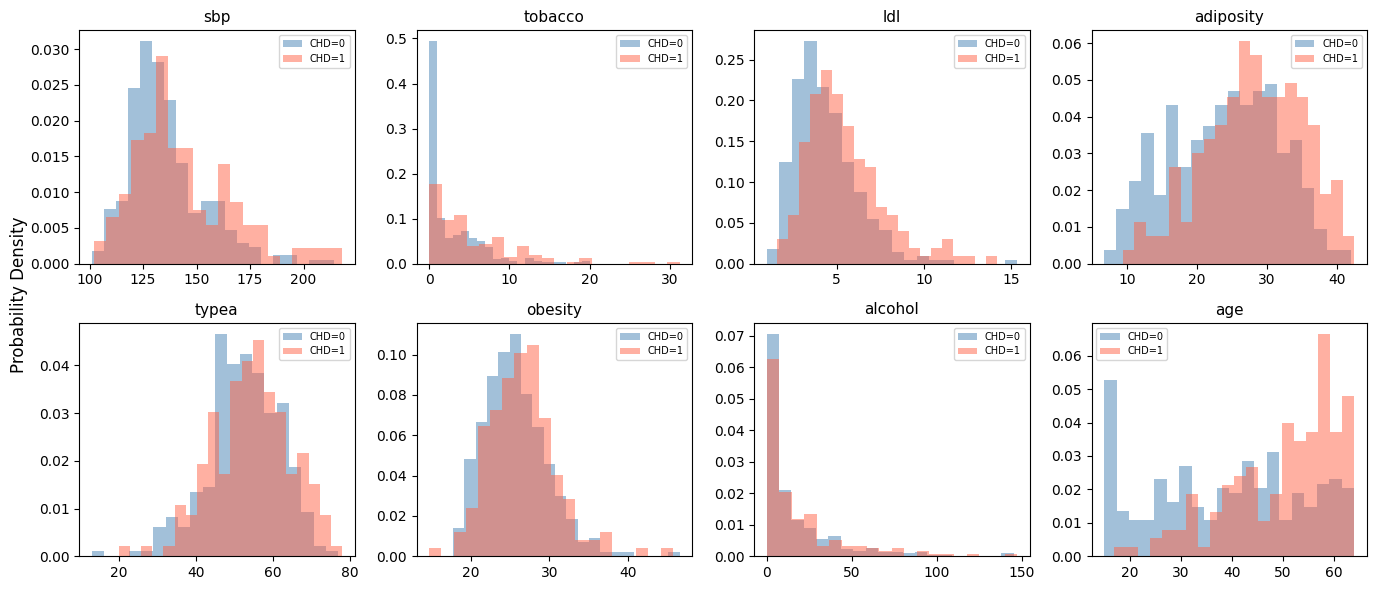

In [ ]:
# plot feature distributions by CHD result
continuous_cols = [
    "sbp",
    "tobacco",
    "ldl",
    "adiposity",
    "typea",
    "obesity",
    "alcohol",
    "age",
]

fig, axes = plt.subplots(2, 4, figsize=(14, 6))
for ax, col in zip(axes.ravel(), continuous_cols):
    for label, colour in [(0, "steelblue"), (1, "tomato")]:
        ax.hist(
            df[df["chd"] == label][col],
            bins=20,
            alpha=0.5,
            label=f"CHD={label}",
            color=colour,
            density=True,
        )
    ax.set_title(col, fontsize=11)
    ax.legend(fontsize=7)
# plt.suptitle("Feature Distributions by CHD Status", fontsize=13, y=1.01)
fig.supylabel("Probability Density", fontsize=12)
plt.tight_layout()
savefig("fig_histograms")
plt.show()

Age, tobacco, and LDL show the clearest separation between CHD positive and negative groups. Tobacco and alcohol are heavily right skewed, with most patients reporting low usage and a long tail extending to heavy users. This skewness does not require transformation because tree based methods are invariant to monotonic transforms and logistic regression with standardised inputs handles it adequately.

### Correlations

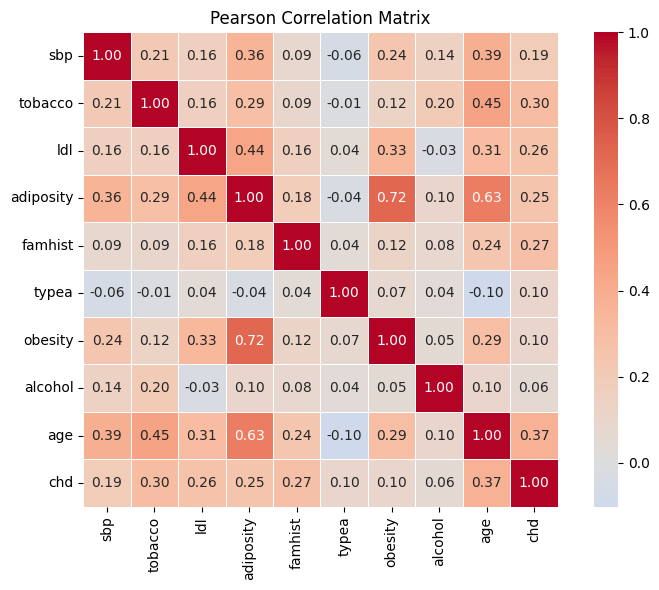

adiposity-obesity correlation: 0.717
adiposity-age correlation:     0.626


In [ ]:
# Correlation heatmap
df_corr = df.copy()
df_corr["famhist"] = LabelEncoder().fit_transform(df_corr["famhist"])

fig, ax = plt.subplots(figsize=(8, 6))
sns.heatmap(
    df_corr.corr(),
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    center=0,
    ax=ax,
    square=True,
    linewidths=0.5,
)
ax.set_title("Pearson Correlation Matrix")
plt.tight_layout()
savefig("fig_correlation")
plt.show()

print(
    f"adiposity-obesity correlation: {df_corr['adiposity'].corr(df_corr['obesity']):.3f}"
)
print(f"adiposity-age correlation:     {df_corr['adiposity'].corr(df_corr['age']):.3f}")

Adiposity and obesity (BMI) are strongly correlated (r = 0.72) because they measure overlapping aspects of body composition. Age correlates with adiposity (r = 0.63) and tobacco (r = 0.45), reflecting cumulative exposure over time. This multicollinearity motivates the use of ridge (L2) regularisation in logistic regression. Without regularisation, coefficient estimates for correlated features become unstable because the model cannot allocate credit between them.

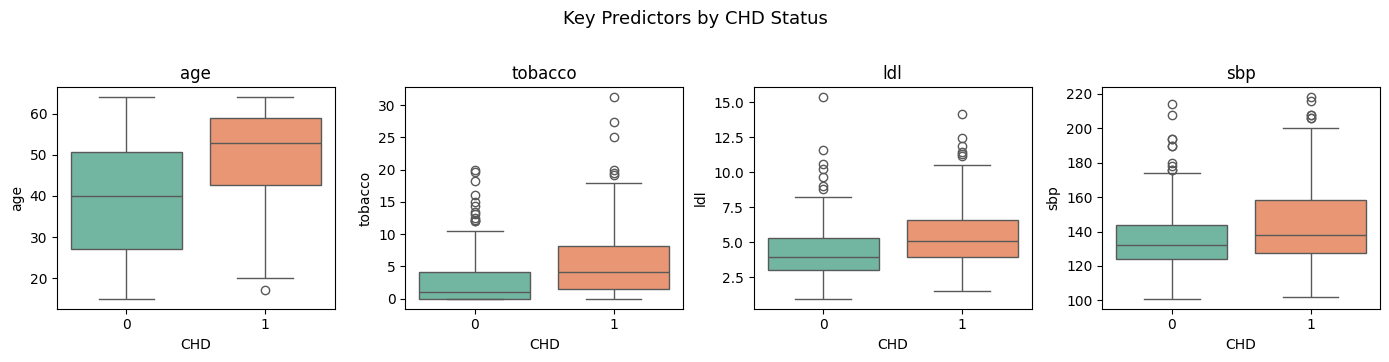

In [ ]:
# Boxplots of key predictors
fig, axes = plt.subplots(1, 4, figsize=(14, 3.5))
for ax, col in zip(axes, ["age", "tobacco", "ldl", "sbp"]):
    sns.boxplot(x="chd", y=col, data=df, ax=ax, palette="Set2")
    ax.set_xlabel("CHD")
    ax.set_title(col)
plt.suptitle("Key Predictors by CHD Status", fontsize=13, y=1.02)
plt.tight_layout()
savefig("fig_boxplots")
plt.show()

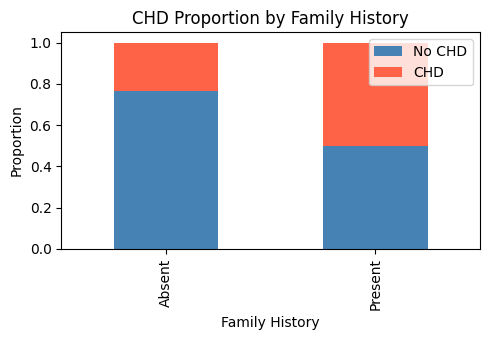

In [ ]:
# Family history and CHD
ct = pd.crosstab(df["famhist"], df["chd"], normalize="index")
ct.plot(kind="bar", stacked=True, color=["steelblue", "tomato"], figsize=(5, 3.5))
plt.title("CHD Proportion by Family History")
plt.ylabel("Proportion")
plt.xlabel("Family History")
plt.legend(["No CHD", "CHD"], loc="upper right")
plt.tight_layout()
savefig("fig_famhist")
plt.show()

### Dimension reduction (PCA, factor analysis, MDS, biplot)

Before classification, the latent structure of the 9 features was explored using PCA, factor analysis, and MDS. This helps to explain why certain classifiers succeed or fail on this dataset.

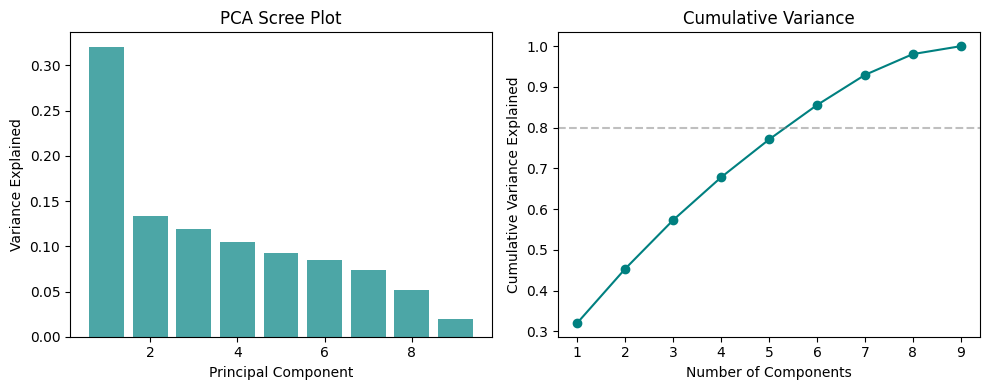

Variance explained by each PC:
  PC1: 0.321 (0.321 cumulative)
  PC2: 0.133 (0.454 cumulative)
  PC3: 0.120 (0.573 cumulative)
  PC4: 0.105 (0.678 cumulative)
  PC5: 0.093 (0.771 cumulative)
  PC6: 0.085 (0.855 cumulative)
  PC7: 0.074 (0.929 cumulative)
  PC8: 0.051 (0.981 cumulative)
  PC9: 0.019 (1.000 cumulative)


In [ ]:
# PCA on standardised features (excluding target)
X_all = df_corr.drop("chd", axis=1)
X_std = StandardScaler().fit_transform(X_all)

pca = PCA().fit(X_std)

# Scree plot - how many components capture meaningful variance?
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(10, 4))

ax1.bar(range(1, 10), pca.explained_variance_ratio_, color="teal", alpha=0.7)
ax1.set_xlabel("Principal Component")
ax1.set_ylabel("Variance Explained")
ax1.set_title("PCA Scree Plot")

ax2.plot(range(1, 10), np.cumsum(pca.explained_variance_ratio_), "o-", color="teal")
ax2.axhline(0.8, ls="--", color="grey", alpha=0.5)
ax2.set_xlabel("Number of Components")
ax2.set_ylabel("Cumulative Variance Explained")
ax2.set_title("Cumulative Variance")

plt.tight_layout()
savefig("fig_pca_scree")
plt.show()

print("Variance explained by each PC:")
for i, v in enumerate(pca.explained_variance_ratio_):
    print(
        f"  PC{i+1}: {v:.3f} ({np.cumsum(pca.explained_variance_ratio_)[i]:.3f} cumulative)"
    )

The first 5 components explain approximately 77% of variance, and 6 are needed to reach 80%. No single component dominates, with PC1 capturing only 32% and the remainder spread broadly across the other components. This diffuse variance structure suggests the data does not collapse neatly into a low dimensional space (foreshadows why non-linear models will not dramatically outperform linear ones).

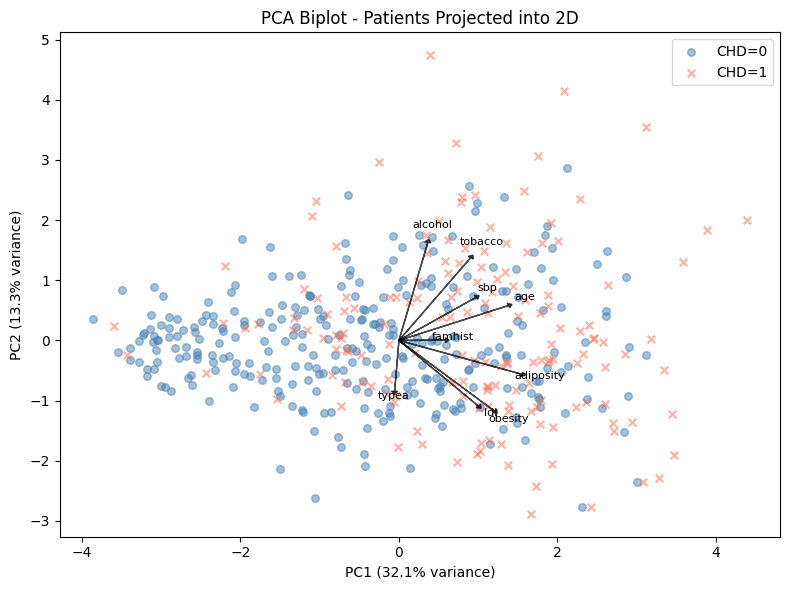

In [ ]:
# PCA biplot - project patients into 2D, colour by CHD
pca2 = PCA(n_components=2).fit(X_std)
X_pca = pca2.transform(X_std)

fig, ax = plt.subplots(figsize=(8, 6))
for label, colour, marker in [(0, "steelblue", "o"), (1, "tomato", "x")]:
    mask = df_corr["chd"] == label
    ax.scatter(X_pca[mask, 0], X_pca[mask, 1], c=colour, marker=marker,
              alpha=0.5, s=30, label=f"CHD={label}")

# Overlay feature loading arrows
loadings = pca2.components_.T
scale = 3  # scale arrows for visibility
for i, feat in enumerate(X_all.columns):
    ax.arrow(0, 0, loadings[i, 0]*scale, loadings[i, 1]*scale,
             head_width=0.08, head_length=0.05, fc="black", ec="black", alpha=0.7)
    ax.text(loadings[i, 0]*scale*1.15, loadings[i, 1]*scale*1.15,
            feat, fontsize=8, ha="center")

ax.set_xlabel(f"PC1 ({pca2.explained_variance_ratio_[0]:.1%} variance)")
ax.set_ylabel(f"PC2 ({pca2.explained_variance_ratio_[1]:.1%} variance)")
ax.set_title("PCA Biplot - Patients Projected into 2D")
ax.legend()
plt.tight_layout()
savefig("fig_pca_biplot")
plt.show()

The two classes overlap substantially in PCA space with no clean separation visible. This confirms the challenge of the classification problem and explains why accuracy plateaus around 74%. The loading arrows show that PC1 is driven by adiposity, obesity, and age (body composition and aging), while PC2 captures tobacco and alcohol (lifestyle factors).

In [ ]:
# Factor Analysis
# q: do interpretable latent factors emerge?
# Try 2 and 3 factors based on the scree plot
for n_factors in [2, 3]:
    fa = FactorAnalysis(n_components=n_factors, random_state=SEED)
    fa.fit(X_std)

    loadings_df = pd.DataFrame(
        fa.components_.T,
        index=X_all.columns,
        columns=[f"Factor {i+1}" for i in range(n_factors)],
    ).round(3)

    print(f"\n{'='*50}")
    print(f"Factor Analysis - {n_factors} factors")
    print(f"{'='*50}")
    print(loadings_df)
    print(f"\nTotal variance explained: {fa.score(X_std):.2f} (log-likelihood)")


Factor Analysis - 2 factors
           Factor 1  Factor 2
sbp           0.419    -0.129
tobacco       0.383    -0.310
ldl           0.455     0.075
adiposity     0.918     0.177
famhist       0.230    -0.105
typea        -0.048     0.141
obesity       0.686     0.492
alcohol       0.118    -0.066
age           0.774    -0.483

Total variance explained: -11.76 (log-likelihood)

Factor Analysis - 3 factors
           Factor 1  Factor 2  Factor 3
sbp          -0.427     0.090     0.104
tobacco      -0.406     0.275     0.173
ldl          -0.445    -0.122    -0.101
adiposity    -0.900    -0.262    -0.002
famhist      -0.238     0.086     0.043
typea         0.058    -0.127     0.077
obesity      -0.641    -0.533     0.017
alcohol      -0.131     0.072     0.723
age          -0.824     0.440    -0.050

Total variance explained: -11.73 (log-likelihood)


With 2 factors, a "metabolic/aging" factor emerges, loading strongly on adiposity (0.92), age (0.77), obesity (0.69), and LDL (0.46). A second factor separates younger, heavier patients from older smokers. 

With 3 factors, alcohol isolates cleanly onto its own factor (loading 0.72), confirming it is statistically independent of the other risk variables. The metabolic factor captures the correlated body composition variables as a single latent dimension, which explains why ridge regression handles their collinearity effectively without discarding either one.

In [ ]:
# Descriptive stats split by CHD 
# to show which features differ between groups
df.groupby("chd").describe().T.round(2)

# more concise mean comparison
df.groupby("chd")[continuous_cols].mean().round(2).T
df.groupby("chd")[continuous_cols].mean().round(2).T.rename(
    columns={0: "No CHD", 1: "CHD"}
)

chd,No CHD,CHD
sbp,135.46,143.74
tobacco,2.63,5.52
ldl,4.34,5.49
adiposity,23.97,28.12
typea,52.37,54.49
obesity,25.74,26.62
alcohol,15.93,19.15
age,38.85,50.29


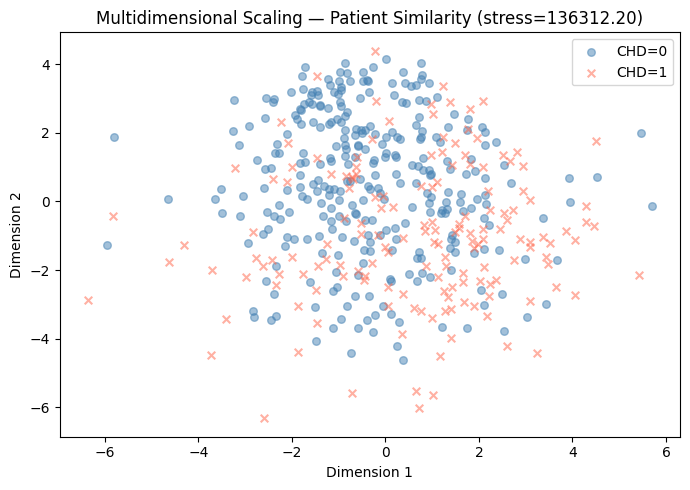

In [ ]:
# Multidimensional scaling
# visualise patient similarity in 2D
# (preserve pairwise distances)
mds = MDS(n_components=2, random_state=SEED, normalized_stress="auto")
X_mds = mds.fit_transform(X_std)

fig, ax = plt.subplots(figsize=(7, 5))
for label, colour, marker in [(0, "steelblue", "o"), (1, "tomato", "x")]:
    mask = df_corr["chd"] == label
    ax.scatter(
        X_mds[mask, 0],
        X_mds[mask, 1],
        c=colour,
        marker=marker,
        alpha=0.5,
        s=30,
        label=f"CHD={label}",
    )
ax.set_title(f"Multidimensional Scaling — Patient Similarity (stress={mds.stress_:.2f})")
ax.legend()
ax.set_xlabel("Dimension 1")
ax.set_ylabel("Dimension 2")
plt.tight_layout()
savefig("fig_mds")
plt.show()

MDS confirms what PCA showed. Healthy and CHD patients occupy overlapping regions of the feature space with no separable clusters. The high stress value indicates that two dimensions are insufficient to preserve all pairwise distances faithfully. 

Note: This overlap is the reason why KNN, which relies on local distance, performs poorly on this dataset compared to a global linear model.

In [ ]:
n_minority = df["chd"].sum()
n_majority = len(df) - n_minority
IR = n_majority / n_minority
p = df.shape[1] - 1  # 9 features, excluding target

print(f"Majority class (healthy): {n_majority}")
print(f"Minority class (CHD+): {n_minority}")
print(f"Imbalance Ratio (IR): {IR:.2f}")
print(f"Feature dimensions (p): {p}")

Majority class (healthy): 302
Minority class (CHD+): 160
Imbalance Ratio (IR): 1.89
Feature dimensions (p): 9


The calculated baseline Imbalance Ratio (IR) is 1.89. Because the effective severity of class imbalance is mathematically mitigated by higher feature dimensionality, this naturally low IR combined with the rich feature space of 9 predictors renders synthetic oversampling (e.g., SMOTE) unnecessary for this dataset.

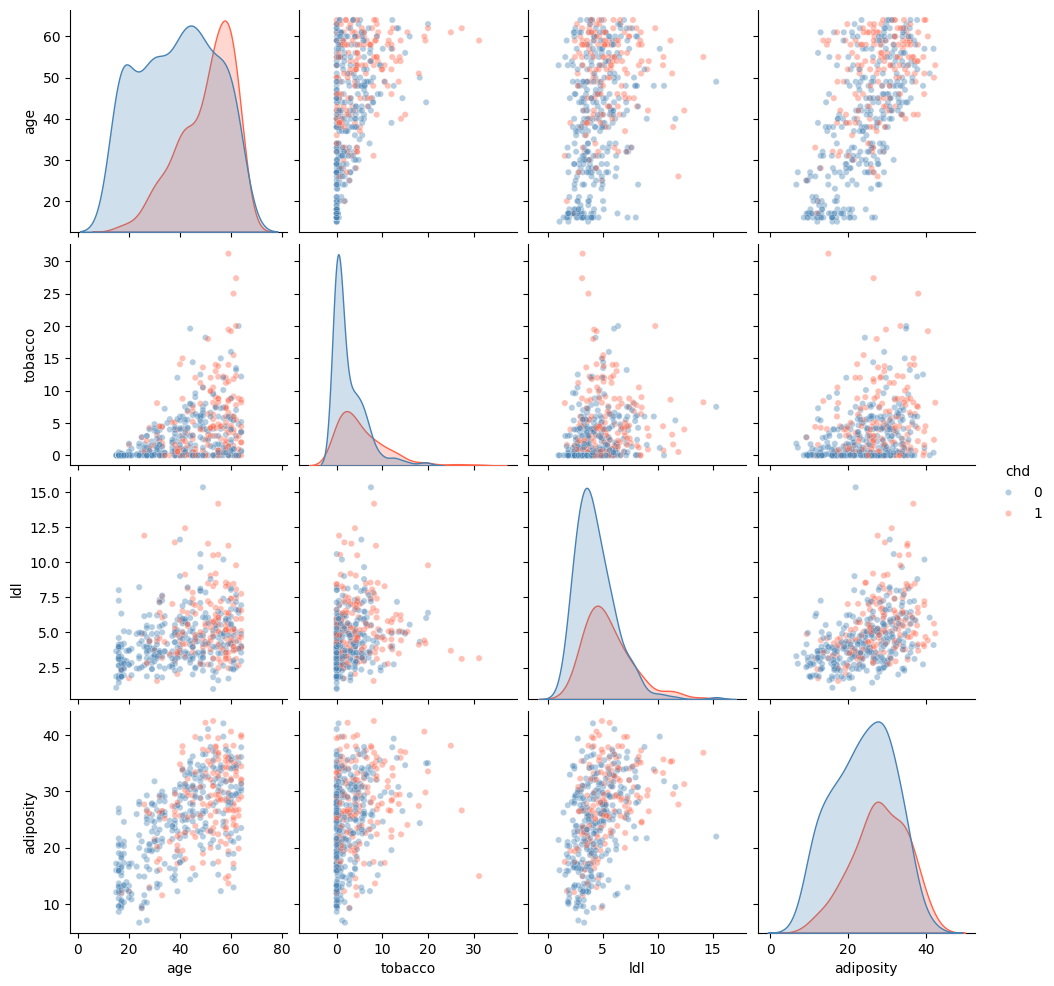

In [ ]:
sns.pairplot(
    df,
    vars=["age", "tobacco", "ldl", "adiposity"],
    hue="chd",
    palette={0: "steelblue", 1: "tomato"},
    diag_kind="kde",
    plot_kws={"alpha": 0.4, "s": 20},
)

The age versus adiposity scatter shows the r = 0.63 correlation visually. Every off diagonal panel confirms the class overlap, with blue and red points interleaved throughout the feature space rather than forming separable clusters. The KDE diagonals show that age provides the clearest marginal separation between groups.

---

## 2. Data Preparation


In [ ]:
# encode famhist
# Absent=0, Present=1
df["famhist"] = LabelEncoder().fit_transform(df["famhist"])

X = df.drop("chd", axis=1)
y = df["chd"]

# stratified 80/20 split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=SEED, stratify=y
)

# Z-standardise using only training set
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Cross validation
# Using same approach for all models for consistency
cv = StratifiedKFold(n_splits=10, shuffle=True, random_state=SEED)

print(f"Training: {X_train.shape[0]} | Test: {X_test.shape[0]}")
print(f"Train CHD rate: {y_train.mean():.3f} | Test CHD rate: {y_test.mean():.3f}")

Training: 369 | Test: 93
Train CHD rate: 0.347 | Test CHD rate: 0.344


---

## 3. Ridge logistic regression (baseline)


### Fit + results

In [ ]:
# Ridge LR
# > L2 penalty addresses adiposity-obesity collinearity
# > C = 1/lambda
# Note: smaller C = stronger regularisation
param_grid_lr = {"C": np.logspace(-4, 4, 20)}

grid_lr = GridSearchCV(
    LogisticRegression(
        penalty="l2",
        solver="lbfgs",
        max_iter=1000,
        random_state=SEED,
    ),
    param_grid_lr,
    cv=cv,
    scoring="accuracy",
    n_jobs=-1,
)
grid_lr.fit(X_train_scaled, y_train)

#!! add additional comments here!!

best_lr = grid_lr.best_estimator_
y_pred_lr = best_lr.predict(X_test_scaled)
y_prob_lr = best_lr.predict_proba(X_test_scaled)[:, 1]
acc_lr = accuracy_score(y_test, y_pred_lr)

print(f"Best C: {grid_lr.best_params_['C']:.4f}")
print(f"CV accuracy: {grid_lr.best_score_:.4f}")
print(f"Test accuracy: {acc_lr:.4f}")
print(f"Test AUC: {roc_auc_score(y_test, y_prob_lr):.4f}")
print(f"Test F1 (CHD): {f1_score(y_test, y_pred_lr):.4f}")
print(f"\n{classification_report(y_test, y_pred_lr, target_names=['No CHD', 'CHD'])}")

Best C: 0.6158
CV accuracy: 0.7426
Test accuracy: 0.7419
Test AUC: 0.8181
Test F1 (CHD): 0.6250

              precision    recall  f1-score   support

      No CHD       0.80      0.80      0.80        61
         CHD       0.62      0.62      0.62        32

    accuracy                           0.74        93
   macro avg       0.71      0.71      0.71        93
weighted avg       0.74      0.74      0.74        93



### Ridge coefficients 

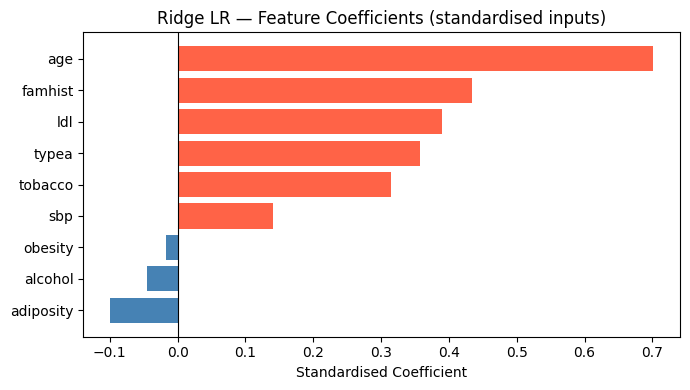

Coefficients and Odds Ratios (descending |magnitude|):
  Feature  Coefficient  Odds Ratio (e^coef)
      age     0.700631             2.015024
  famhist     0.433724             1.542993
      ldl     0.389561             1.476332
    typea     0.357234             1.429370
  tobacco     0.314976             1.370227
      sbp     0.140667             1.151041
adiposity    -0.099138             0.905617
  alcohol    -0.045790             0.955242
  obesity    -0.017416             0.982735


In [ ]:
# Standardised coefficients
# > key interpretability advantage of ridge LR
coef_df = pd.DataFrame(
    {"Feature": X.columns, "Coefficient": best_lr.coef_[0]}
).sort_values("Coefficient")

fig, ax = plt.subplots(figsize=(7, 4))
colours = ["tomato" if c > 0 else "steelblue" for c in coef_df["Coefficient"]]
ax.barh(coef_df["Feature"], coef_df["Coefficient"], color=colours)
ax.set_xlabel("Standardised Coefficient")
ax.set_title("Ridge LR — Feature Coefficients (standardised inputs)")
ax.axvline(0, color="black", linewidth=0.8)
plt.tight_layout()
savefig("fig_ridge_coefficients")
plt.show()


coef_df["Odds Ratio (e^coef)"] = np.exp(coef_df["Coefficient"])
print("Coefficients and Odds Ratios (descending |magnitude|):")
print(
    coef_df.sort_values("Coefficient", key=abs, ascending=False)
    .round(6)
    .to_string(index=False)
)

Because all features are standardised to zero mean and unit variance, the coefficients are directly comparable in magnitude.

- **Age (0.70) is the strongest predictor**. Each standard deviation increase in age (approximately 15 years) roughly doubles the odds of CHD: 
  $$\exp(0.70) = 2.01\ldots$$

- **Family history (0.43) is the second strongest**. Having a family history of   heart disease is a substantial independent risk factor that cannot be modified by lifestyle changes

- **LDL cholesterol (0.39) increases risk** as expected from cardiovascular   epidemiology - **Type A behaviour (0.36)** reflects psychological stress contributing meaningfully to CHD risk, consistent with the literature on stress and cardiovascular outcomes

- **Tobacco (0.31)** captures cumulative smoking exposure as a risk factor

- **Blood pressure (0.14)** contributes modestly once other factors are accounted   for

- **Adiposity (−0.10) and obesity (−0.02) receive near zero coefficients**. This does not mean body composition is irrelevant. The ridge penalty distributes   their shared effect evenly because of their high correlation (r = 0.72),   rather than assigning it to either one. The combined metabolic signal is   visible in the factor analysis where both load on the same latent factor. 

- **Alcohol (−0.05) contributes almost nothing to prediction**. Although alcohol   isolated onto its own factor in the factor analysis (Factor 3 loading = 0.72), that information does not improve CHD prediction once age, tobacco, and family history are in the model. Current drinking appears to be a poor proxy for cumulative cardiovascular damage compared to lifetime tobacco exposure. 

### Elastic net comparison


In [ ]:
enet = GridSearchCV(
    LogisticRegression(
        penalty="elasticnet",
        solver="saga",
        max_iter=5000,
        random_state=SEED,
        l1_ratio=0.5,
    ),
    {"C": np.logspace(-4, 4, 20), "l1_ratio": [0.1, 0.3, 0.5, 0.7, 0.9]},
    cv=cv,
    scoring="accuracy",
    n_jobs=-1,
)
enet.fit(X_train_scaled, y_train)

enet_coefs = pd.DataFrame(
    {
        "Feature": X.columns,
        "Ridge": best_lr.coef_[0],
        "Elastic Net": enet.best_estimator_.coef_[0],
    }
).round(4)
print(f"Best l1_ratio: {enet.best_params_['l1_ratio']}")
print(
    f"Elastic Net test accuracy: {accuracy_score(y_test, enet.predict(X_test_scaled)):.3f}"
)
print(enet_coefs.to_string(index=False))

Best l1_ratio: 0.5
Elastic Net test accuracy: 0.742
  Feature   Ridge  Elastic Net
      sbp  0.1407       0.0635
  tobacco  0.3150       0.2330
      ldl  0.3896       0.2911
adiposity -0.0991       0.0000
  famhist  0.4337       0.3431
    typea  0.3572       0.2230
  obesity -0.0174       0.0000
  alcohol -0.0458       0.0000
      age  0.7006       0.5415


The elastic net $(l_1\;\text{ratio}=0.5)$ achieves identical test accuracy to ridge while zeroing out adiposity, obesity, and alcohol. This confirms the permutation importance findings: these variables carry no independent predictive signal beyond what age, tobacco, LDL, family history, Type-A behaviour, and blood pressure already provide. 

Ridge retains them with near-zero coefficients and elastic net removes them entirely but methods both agree and arrive at the same predictions.

### Ridge: confusion matrix & calibration

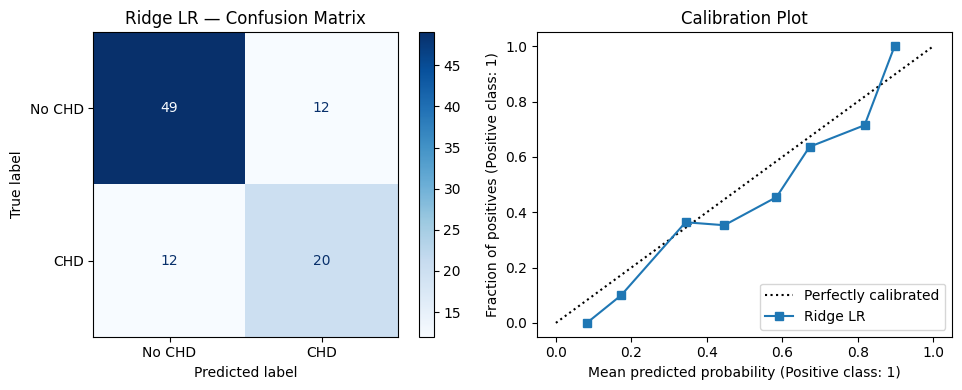

In [ ]:
# Confusion matrix + calibration plot side by side
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(10, 4))

ConfusionMatrixDisplay.from_predictions(
    y_test, y_pred_lr, ax=ax1, cmap="Blues",
    display_labels=["No CHD", "CHD"])
ax1.set_title("Ridge LR — Confusion Matrix")

CalibrationDisplay.from_predictions(
    y_test, y_prob_lr, n_bins=8, ax=ax2, name="Ridge LR")
ax2.set_title("Calibration Plot")

plt.tight_layout()
savefig("fig_ridge_cm_calibration")
plt.show()

The calibration plot shows how well predicted probabilities match observed frequencies. A perfectly calibrated model follows the diagonal: if it predicts 40% risk, roughly 40% of those patients should actually have CHD. 

The model is reasonably well calibrated overall, though it slightly overestimates risk in the 0.4 to 0.7 range where the curve dips below the diagonal. With only 93 test patients, each calibration bin contains roughly 10 patients, so individual points can shift substantially due to sampling noise.

### Permutation importance

In [ ]:
perm = permutation_importance(
    best_lr, X_test_scaled, y_test, n_repeats=30, random_state=SEED
)
perm_df = pd.DataFrame(
    {
        "Feature": X.columns,
        "Importance": perm.importances_mean,
        "Std": perm.importances_std,
    }
).sort_values("Importance", ascending=False)
print(perm_df.to_string(index=False))

  Feature  Importance      Std
      age    0.054122 0.040565
  famhist    0.052330 0.026879
  tobacco    0.032616 0.021050
    typea    0.021147 0.025669
      sbp    0.006452 0.018121
adiposity    0.000000 0.012723
  obesity   -0.005018 0.005364
      ldl   -0.006452 0.026572
  alcohol   -0.008244 0.004548


Permutation importance provides a model agnostic measure of feature relevance. It works by randomly shuffling one feature's values and measuring how much accuracy drops. A large drop means the feature was important. A drop near zero means other features already carry the same information. A negative value means the model performs slightly better without the feature.

Age and family history are confirmed as the dominant predictors, consistent with the ridge coefficients. LDL, despite having the third largest ridge coefficient (0.39), shows negligible permutation importance. This apparent contradiction reflects shared information: LDL correlates with the same metabolic aging axis identified in the factor analysis, so its predictive signal is already captured by age, adiposity, and tobacco when those features are present.

From a clinical perspective, this does not mean LDL is unimportant for heart disease. It means that in this 9 feature model, LDL acts through the same causal pathways as other metabolic variables rather than as an independent risk channel. A clinician would still treat elevated LDL, but a predictive model gains little by including it alongside the correlated features.

In the report this point was made mostly in a caption due to the 1000 word limit. Report is designed for a machine learning audience, but worth mentioning in more detail here. 

### SHAP (ridge)

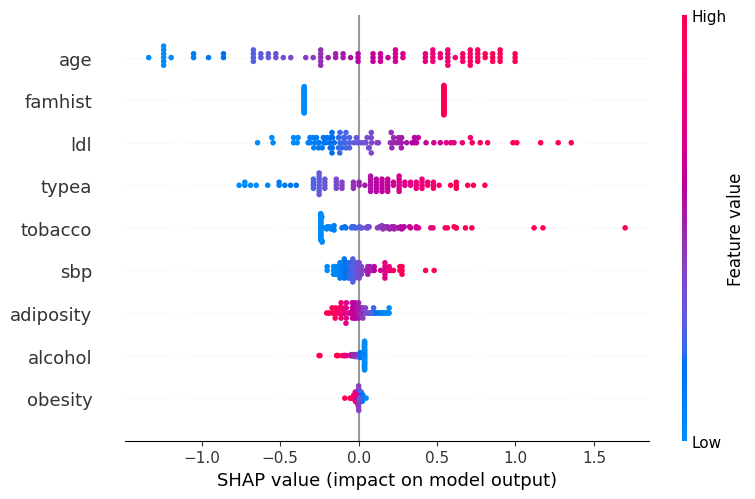

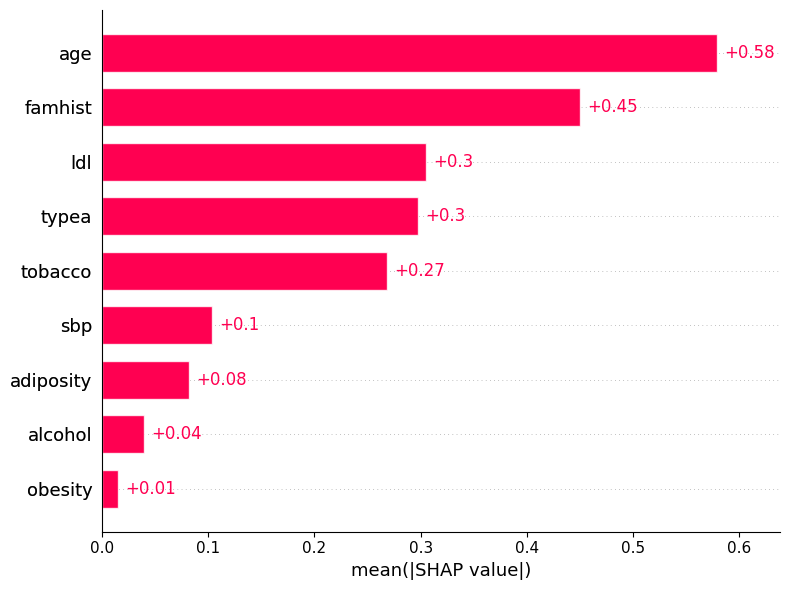

In [ ]:
# SHAP for Ridge LR 
# (linear model — exact SHAP values, no approximation)
explainer = shap.LinearExplainer(
    best_lr, X_train_scaled, feature_names=X.columns.tolist()
)
shap_values = explainer.shap_values(X_test_scaled)

# Summary plot — replaces/unifies all three importance methods
fig, ax = plt.subplots()
shap.summary_plot(
    shap_values, X_test_scaled, feature_names=X.columns.tolist(), show=False
)
plt.tight_layout()
savefig("fig_shap_summary")
plt.show()

shap.plots.bar(explainer(X_test_scaled), show=False)
plt.tight_layout()
savefig("fig_shap_bar")
plt.show()

High age (red dots on the right) strongly pushes predictions toward CHD, while low age (blue dots on the left) pushes away from it. Family history shows a clean binary split: present (red) contributes positively, absent (blue) contributes negatively. LDL, Type A behaviour, and tobacco show the expected positive relationship between higher values and increased CHD risk. Adiposity, alcohol, and obesity cluster tightly around zero, confirming their negligible marginal contribution to individual predictions.

The SHAP bar plot shows mean absolute SHAP values across all 93 test patients, providing a single global importance ranking. Age dominates at 0.58, followed by family history (0.45), LDL (0.30), Type A behaviour (0.30), and tobacco (0.27). Blood pressure, adiposity, alcohol, and obesity contribute progressively less. This ordering matches the ridge coefficients almost exactly (age 0.70, famhist 0.43, LDL 0.39, typeA 0.36, tobacco 0.31), confirming that the linear model is capturing the true importance structure. The agreement between coefficients and SHAP values is expected for a linear model, since SHAP values for linear models reduce to the product of the coefficient and the feature value.

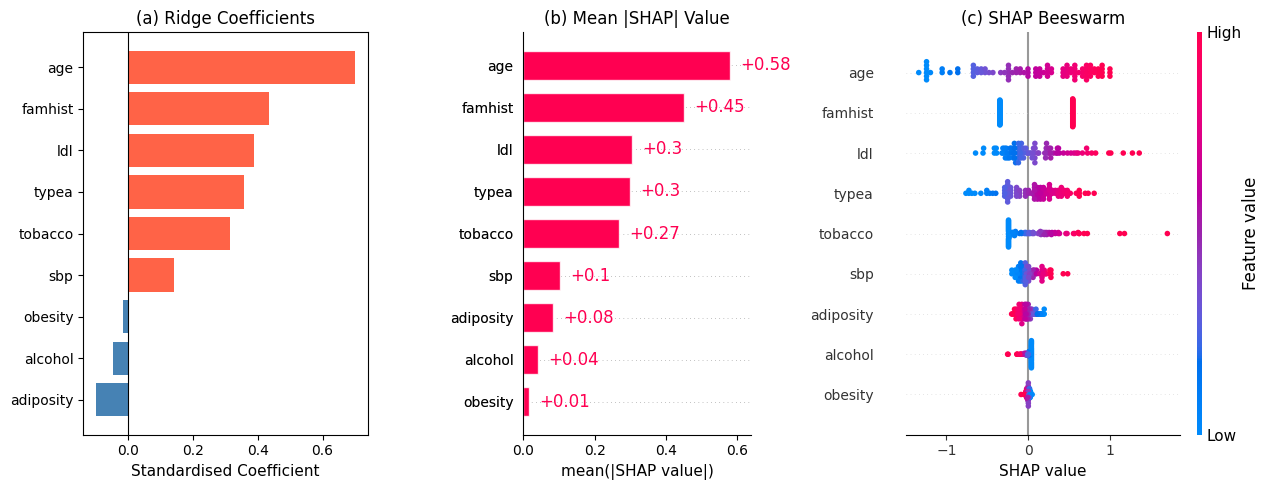

In [ ]:
# - Triple panel: Ridge coefficients + SHAP bar + SHAP beeswarm -
fig, (ax1, ax2, ax3) = plt.subplots(
    1,
    3,
    figsize=(18, 6),
    gridspec_kw={
        "width_ratios": [1.0, 0.8, 1.2]
    },  # give coeff panel more room for labels
)

# --- Left: standardised coefficients ---
coef_df = pd.DataFrame(
    {"Feature": X.columns, "Coefficient": best_lr.coef_[0]}
).sort_values("Coefficient")
colours = ["tomato" if c > 0 else "steelblue" for c in coef_df["Coefficient"]]
ax1.barh(coef_df["Feature"], coef_df["Coefficient"], color=colours)
ax1.set_xlabel("Standardised Coefficient")
ax1.set_title("(a) Ridge Coefficients")
ax1.axvline(0, color="black", linewidth=0.8)

# --- Centre: SHAP bar (mean |SHAP|) ---
explainer = shap.LinearExplainer(
    best_lr, X_train_scaled, feature_names=X.columns.tolist()
)
shap_vals = explainer(X_test_scaled)
plt.sca(ax2)
shap.plots.bar(shap_vals, show=False)
ax2.set_title("(b) Mean |SHAP| Value")
# ax2.set_yticklabels([])  
ax2.set_ylabel("")

# --- Right: SHAP beeswarm ---
plt.sca(ax3)
shap.summary_plot(
    shap_vals.values,
    X_test_scaled,
    feature_names=X.columns.tolist(),
    show=False,
)
ax3.set_title("(c) SHAP Beeswarm")
# ax3.set_yticklabels([])  
ax3.set_ylabel("")
ax3.set_xlabel("SHAP value")  # replace default label

# --- Set same font sizes ---
TICK_SIZE = 10
LABEL_SIZE = 11
TITLE_SIZE = 12
for ax in (ax1, ax2, ax3):
    ax.tick_params(axis="both", labelsize=TICK_SIZE)
    ax.xaxis.label.set_size(LABEL_SIZE)
    ax.title.set_size(TITLE_SIZE)

fig.set_size_inches(13, 5)

plt.tight_layout()
savefig("fig_ridge_coef_shap_bee")
plt.show()

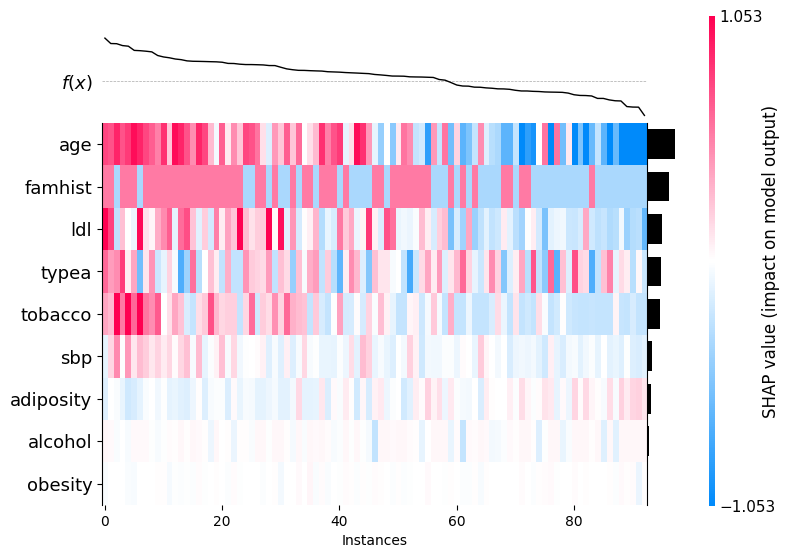

In [ ]:
explanation = explainer(X_test_scaled)
order = np.argsort(-explanation.values.sum(axis=1))

shap.plots.heatmap(explanation, instance_order=order, show=False)
plt.tight_layout()
savefig("fig_shap_heatmap")
plt.show()

Type A behaviour is the only top five predictor that does not follow the descending risk gradient. Its SHAP contributions appear mixed across the entire risk spectrum, indicating that psychological stress operates as an independent risk pathway orthogonal to the metabolic and lifestyle factors. 

This is consistent with the correlation matrix, where Type A shows near zero correlation with all other features, and with the factor analysis, where it did not load on either latent factor.

### Learning curve

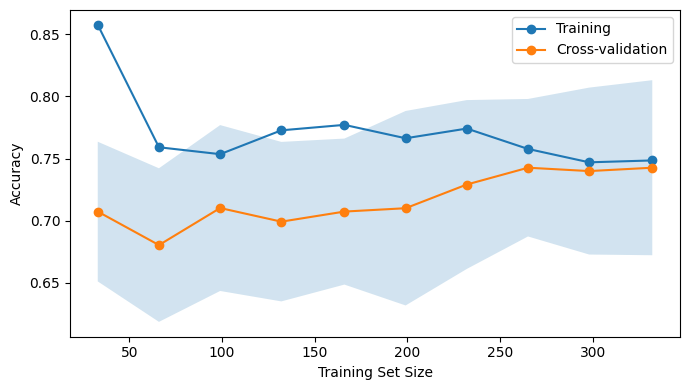

In [ ]:
train_sizes, train_scores, val_scores = learning_curve(
    best_lr,
    X_train_scaled,
    y_train,
    cv=cv,
    train_sizes=np.linspace(0.1, 1.0, 10),
    scoring="accuracy",
)

fig, ax = plt.subplots(figsize=(7, 4))
ax.plot(train_sizes, train_scores.mean(axis=1), "o-", label="Training")
ax.plot(train_sizes, val_scores.mean(axis=1), "o-", label="Cross-validation")
ax.fill_between(
    train_sizes,
    val_scores.mean(axis=1) - val_scores.std(axis=1),
    val_scores.mean(axis=1) + val_scores.std(axis=1),
    alpha=0.2,
)
ax.set_xlabel("Training Set Size")
ax.set_ylabel("Accuracy")
# ax.set_title("Learning Curve — Ridge LR")
ax.legend()
plt.tight_layout()
savefig("fig_learning_curve")
plt.show()

The learning curves converge at full sample size. Training accuracy decreases as more data is added (the model cannot memorise larger datasets), while cross validation accuracy rises gradually and plateaus around 74%. 

The convergence indicates that the model has extracted most of the available signal from the data. More patients would provide marginal improvements, but the approximately 74% ceiling may be a property of the problem itself (overlapping classes in feature space) rather than insufficient training data.

---
## 4. Alternative Classifiers

Six additional classifiers are evaluated, each testing a different hypothesis about the data structure. All are tuned using the same 10 fold stratified cross validation framework as the ridge baseline to ensure fair comparison. Hyperparameters are optimised via grid search over candidate values.

### Evaluate model function

In [ ]:
# Storage for all model results
results = {}

def evaluate_model(name, grid, X_tr, X_te, y_tr, y_te):
    """Fit via GridSearchCV, evaluate, store results."""
    grid.fit(X_tr, y_tr)
    best = grid.best_estimator_
    y_pred = best.predict(X_te)
    y_prob = best.predict_proba(X_te)[:, 1] if hasattr(best, "predict_proba") else None
    
    acc = accuracy_score(y_te, y_pred)
    auc = roc_auc_score(y_te, y_prob) if y_prob is not None else np.nan
    f1 = f1_score(y_te, y_pred)
    
    results[name] = {
        "model": best, "cv_acc": grid.best_score_,
        "test_acc": acc, "test_auc": auc, "test_f1": f1,
        "best_params": grid.best_params_,
        "y_pred": y_pred, "y_prob": y_prob
    }
    print(f"{name:25s} | CV={grid.best_score_:.3f} | Test={acc:.3f} | "
          f"AUC={auc:.3f} | F1={f1:.3f} | {grid.best_params_}")
    return best

### Individual classifier evaluation: KNN, RF, SVM, GB, XGBOost, Ridge+FA

In [ ]:
# Add ridge LR to results
results["Ridge LR"] = {
    "model": best_lr, "cv_acc": grid_lr.best_score_,
    "test_acc": acc_lr, "test_auc": roc_auc_score(y_test, y_prob_lr),
    "test_f1": f1_score(y_test, y_pred_lr),
    "best_params": grid_lr.best_params_,
    "y_pred": y_pred_lr, "y_prob": y_prob_lr
}

print(f"{'Model':25s} | {'CV':>5s} | {'Test':>5s} | {'AUC':>5s} | {'F1':>5s} | Best params")
print("-" * 90)
print(f"{'Ridge LR':25s} | {grid_lr.best_score_:.3f} | {acc_lr:.3f} | "
      f"{roc_auc_score(y_test, y_prob_lr):.3f} | {f1_score(y_test, y_pred_lr):.3f} | "
      f"{grid_lr.best_params_}")

Model                     |    CV |  Test |   AUC |    F1 | Best params
------------------------------------------------------------------------------------------
Ridge LR                  | 0.743 | 0.742 | 0.818 | 0.625 | {'C': np.float64(0.615848211066026)}


In [ ]:
# KNN — tests whether local patient similarity predicts better than global linear trends
evaluate_model("KNN", GridSearchCV(
    KNeighborsClassifier(),
    {"n_neighbors": list(range(3, 31, 2)), "weights": ["uniform", "distance"]},
    cv=cv, scoring="accuracy", n_jobs=-1
), X_train_scaled, X_test_scaled, y_train, y_test)

KNN                       | CV=0.743 | Test=0.677 | AUC=0.752 | F1=0.483 | {'n_neighbors': 15, 'weights': 'uniform'}


,"n_neighbors n_neighbors: int, default=5Number of neighbors to use by default for :meth:`kneighbors` queries.",15
,"weights weights: {'uniform', 'distance'}, callable or None, default='uniform'Weight function used in prediction. Possible values:- 'uniform' : uniform weights. All points in each neighborhood are weighted equally.- 'distance' : weight points by the inverse of their distance. in this case, closer neighbors of a query point will have a greater influence than neighbors which are further away.- [callable] : a user-defined function which accepts an array of distances, and returns an array of the same shape containing the weights.Refer to the example entitled:ref:`sphx_glr_auto_examples_neighbors_plot_classification.py`showing the impact of the `weights` parameter on the decisionboundary.",'uniform'
,"algorithm algorithm: {'auto', 'ball_tree', 'kd_tree', 'brute'}, default='auto'Algorithm used to compute the nearest neighbors:- 'ball_tree' will use :class:`BallTree`- 'kd_tree' will use :class:`KDTree`- 'brute' will use a brute-force search.- 'auto' will attempt to decide the most appropriate algorithm based on the values passed to :meth:`fit` method.Note: fitting on sparse input will override the setting ofthis parameter, using brute force.",'auto'
,"leaf_size leaf_size: int, default=30Leaf size passed to BallTree or KDTree. This can affect thespeed of the construction and query, as well as the memoryrequired to store the tree. The optimal value depends on thenature of the problem.",30
,"p p: float, default=2Power parameter for the Minkowski metric. When p = 1, this is equivalentto using manhattan_distance (l1), and euclidean_distance (l2) for p = 2.For arbitrary p, minkowski_distance (l_p) is used. This parameter is expectedto be positive.",2
,"metric metric: str or callable, default='minkowski'Metric to use for distance computation. Default is ""minkowski"", whichresults in the standard Euclidean distance when p = 2. See thedocumentation of `scipy.spatial.distance`_ andthe metrics listed in:class:`~sklearn.metrics.pairwise.distance_metrics` for valid metricvalues.If metric is ""precomputed"", X is assumed to be a distance matrix andmust be square during fit. X may be a :term:`sparse graph`, in whichcase only ""nonzero"" elements may be considered neighbors.If metric is a callable function, it takes two arrays representing 1Dvectors as inputs and must return one value indicating the distancebetween those vectors. This works for Scipy's metrics, but is lessefficient than passing the metric name as a string.",'minkowski'
,"metric_params metric_params: dict, default=NoneAdditional keyword arguments for the metric function.",None
,"n_jobs n_jobs: int, default=NoneThe number of parallel jobs to run for neighbors search.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details.Doesn't affect :meth:`fit` method.",None


In [ ]:
# Random Forest — tests non-linear feature interactions
evaluate_model("Random Forest", GridSearchCV(
    RandomForestClassifier(random_state=SEED),
    {"n_estimators": [100, 200, 300], "max_depth": [3, 5, 7, None],
     "min_samples_split": [2, 5, 10]},
    cv=cv, scoring="accuracy", n_jobs=-1
), X_train_scaled, X_test_scaled, y_train, y_test)

Random Forest             | CV=0.729 | Test=0.710 | AUC=0.779 | F1=0.509 | {'max_depth': 3, 'min_samples_split': 10, 'n_estimators': 100}


,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",3
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",10
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstrap: bool, default=TrueWhether bootstrap samples are used when building trees. If False, thewhole dataset is used to build each tree.",True
,"oob_score oob_score: bool or callable, default=FalseWhether to use out-of-bag samples to estimate the generalization score.By default, :func:`~sklearn.metrics.accuracy_score` is used.Provide a callable with signature `metric(y

In [ ]:
# SVM (RBF) — tests non-linear class boundaries via kernel projection
evaluate_model("SVM (RBF)", GridSearchCV(
    SVC(kernel="rbf", random_state=SEED, probability=True),
    {"C": [0.1, 1, 10, 100], "gamma": ["scale", "auto", 0.01, 0.1]},
    cv=cv, scoring="accuracy", n_jobs=-1
), X_train_scaled, X_test_scaled, y_train, y_test)

SVM (RBF)                 | CV=0.748 | Test=0.720 | AUC=0.758 | F1=0.581 | {'C': 100, 'gamma': 0.01}


,"C C: float, default=1.0Regularization parameter. The strength of the regularization isinversely proportional to C. Must be strictly positive. The penaltyis a squared l2 penalty. For an intuitive visualization of the effectsof scaling the regularization parameter C, see:ref:`sphx_glr_auto_examples_svm_plot_svm_scale_c.py`.",100
,"kernel kernel: {'linear', 'poly', 'rbf', 'sigmoid', 'precomputed'} or callable, default='rbf'Specifies the kernel type to be used in the algorithm. Ifnone is given, 'rbf' will be used. If a callable is given it is used topre-compute the kernel matrix from data matrices; that matrix should bean array of shape ``(n_samples, n_samples)``. For an intuitivevisualization of different kernel types see:ref:`sphx_glr_auto_examples_svm_plot_svm_kernels.py`.",'rbf'
,"degree degree: int, default=3Degree of the polynomial kernel function ('poly').Must be non-negative. Ignored by all other kernels.",3
,"gamma gamma: {'scale', 'auto'} or float, default='scale'Kernel coefficient for 'rbf', 'poly' and 'sigmoid'.- if ``gamma='scale'`` (default) is passed then it uses 1 / (n_features * X.var()) as value of gamma,- if 'auto', uses 1 / n_features- if float, must be non-negative... versionchanged:: 0.22 The default value of ``gamma`` changed from 'auto' to 'scale'.",0.01
,"coef0 coef0: float, default=0.0Independent term in kernel function.It is only significant in 'poly' and 'sigmoid'.",0.0
,"shrinking shrinking: bool, default=TrueWhether to use the shrinking heuristic.See the :ref:`User Guide `.",True
,"probability probability: bool, default=FalseWhether to enable probability estimates. This must be enabled priorto calling `fit`, will slow down that method as it internally uses5-fold cross-validation, and `predict_proba` may be inconsistent with`predict`. Read more in the :ref:`User Guide `.",True
,"tol tol: float, default=1e-3Tolerance for stopping criterion.",0.001
,"cache_size cache_size: float, default=200Specify the size of the kernel cache (in MB).",200
,"class_weight class_weight: dict or 'balanced', default=NoneSet the parameter C of class i to class_weight[i]*C forSVC. If not given, all classes are supposed to haveweight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.",None
,"verbose verbose: bool, default=FalseEnable verbose output. Note that this setting takes advantage of aper-process runtime setting in libsvm that, if enabled, may not workproperly in a multithreaded context.",False


In [ ]:
# Gradient Boosting — sequential correction of errors, handles non-linearity
# Goes beyond the basic module classifiers (Rui encouraged this)
evaluate_model("Gradient Boosting", GridSearchCV(
    GradientBoostingClassifier(random_state=SEED),
    {"n_estimators": [100, 200], "max_depth": [2, 3, 4],
     "learning_rate": [0.05, 0.1, 0.2], "subsample": [0.8, 1.0]},
    cv=cv, scoring="accuracy", n_jobs=-1
), X_train_scaled, X_test_scaled, y_train, y_test)

Gradient Boosting         | CV=0.697 | Test=0.763 | AUC=0.793 | F1=0.645 | {'learning_rate': 0.05, 'max_depth': 2, 'n_estimators': 100, 'subsample': 1.0}


,"loss loss: {'log_loss', 'exponential'}, default='log_loss'The loss function to be optimized. 'log_loss' refers to binomial andmultinomial deviance, the same as used in logistic regression.It is a good choice for classification with probabilistic outputs.For loss 'exponential', gradient boosting recovers the AdaBoost algorithm.",'log_loss'
,"learning_rate learning_rate: float, default=0.1Learning rate shrinks the contribution of each tree by `learning_rate`.There is a trade-off between learning_rate and n_estimators.Values must be in the range `[0.0, inf)`.For an example of the effects of this parameter and its interaction with``subsample``, see:ref:`sphx_glr_auto_examples_ensemble_plot_gradient_boosting_regularization.py`.",0.05
,"n_estimators n_estimators: int, default=100The number of boosting stages to perform. Gradient boostingis fairly robust to over-fitting so a large number usuallyresults in better performance.Values must be in the range `[1, inf)`.",100
,"subsample subsample: float, default=1.0The fraction of samples to be used for fitting the individual baselearners. If smaller than 1.0 this results in Stochastic GradientBoosting. `subsample` interacts with the parameter `n_estimators`.Choosing `subsample < 1.0` leads to a reduction of varianceand an increase in bias.Values must be in the range `(0.0, 1.0]`.",1.0
,"criterion criterion: {'friedman_mse', 'squared_error'}, default='friedman_mse'The function to measure the quality of a split. Supported criteria are'friedman_mse' for the mean squared error with improvement score byFriedman, 'squared_error' for mean squared error. The default value of'friedman_mse' is generally the best as it can provide a betterapproximation in some cases... versionadded:: 0.18",'friedman_mse'
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, values must be in the range `[2, inf)`.- If float, values must be in the range `(0.0, 1.0]` and `min_samples_split` will be `ceil(min_samples_split * n_samples)`... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, values must be in the range `[1, inf)`.- If float, values must be in the range `(0.0, 1.0)` and `min_samples_leaf` will be `ceil(min_samples_leaf * n_samples)`... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.Values must be in the range `[0.0, 0.5]`.",0.0
,"max_depth max_depth: int or None, default=3Maximum depth of the individual regression estimators. The maximumdepth limits the number of nodes in the tree. Tune this parameterfor best performance; the best value depends on the interactionof the input variables. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.If int, values must be in the range `[1, inf)`.",2
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.Values must be in the range `[0.0, inf)`.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``,

In [ ]:
# Ridge LR with factor scores as inputs (instead of raw features)
# Tests whether dimension reduction improves classification
fa3 = FactorAnalysis(n_components=3, random_state=SEED)
X_train_fa = fa3.fit_transform(X_train_scaled)
X_test_fa = fa3.transform(X_test_scaled)

evaluate_model("Ridge LR (FA inputs)", GridSearchCV(
    LogisticRegression(penalty="l2", solver="lbfgs", max_iter=1000,
                       random_state=SEED),
    {"C": np.logspace(-4, 4, 20)},
    cv=cv, scoring="accuracy", n_jobs=-1
), X_train_fa, X_test_fa, y_train, y_test)

Ridge LR (FA inputs)      | CV=0.688 | Test=0.763 | AUC=0.809 | F1=0.621 | {'C': np.float64(0.23357214690901212)}


,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'l2'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",np.float64(0....7214690901212)
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation `) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary ` for details.",42
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solver because it works reasonably well for a wide class of problems

In [ ]:
from xgboost import XGBClassifier

evaluate_model("XGBoost", GridSearchCV(
    XGBClassifier(random_state=SEED, eval_metric="logloss",
                  use_label_encoder=False),
    {"n_estimators": [100, 200], "max_depth": [2, 3, 4],
     "learning_rate": [0.05, 0.1, 0.2], "subsample": [0.8, 1.0],
     "reg_lambda": [1, 5, 10]},  # L2 regularisation — connects to ridge discussion
    cv=cv, scoring="accuracy", n_jobs=-1
), X_train_scaled, X_test_scaled, y_train, y_test)

XGBoost                   | CV=0.710 | Test=0.753 | AUC=0.789 | F1=0.623 | {'learning_rate': 0.05, 'max_depth': 2, 'n_estimators': 100, 'reg_lambda': 5, 'subsample': 0.8}


,"objective objective: typing.Union[str, xgboost.sklearn._SklObjWProto, typing.Callable[[typing.Any, typing.Any], typing.Tuple[numpy.ndarray, numpy.ndarray]], NoneType]Specify the learning task and the corresponding learning objective or a customobjective function to be used.For custom objective, see :doc:`/tutorials/custom_metric_obj` and:ref:`custom-obj-metric` for more information, along with the end note forfunction signatures.",'binary:logistic'
,"base_score base_score: typing.Union[float, typing.List[float], NoneType]The initial prediction score of all instances, global bias.",None
,booster,None
,"callbacks callbacks: typing.Optional[typing.List[xgboost.callback.TrainingCallback]]List of callback functions that are applied at end of each iteration.It is possible to use predefined callbacks by using:ref:`Callback API `... note:: States in callback are not preserved during training, which means callback objects can not be reused for multiple training sessions without reinitialization or deepcopy... code-block:: python for params in parameters_grid: # be sure to (re)initialize the callbacks before each run callbacks = [xgb.callback.LearningRateScheduler(custom_rates)] reg = xgboost.XGBRegressor(**params, callbacks=callbacks) reg.fit(X, y)",None
,colsample_bylevel colsample_bylevel: typing.Optional[float]Subsample ratio of columns for each level.,None
,colsample_bynode colsample_bynode: typing.Optional[float]Subsample ratio of columns for each split.,None
,colsample_bytree colsample_bytree: typing.Optional[float]Subsample ratio of columns when constructing each tree.,None
,"device device: typing.Optional[str].. versionadded:: 2.0.0Device ordinal, available options are `cpu`, `cuda`, and `gpu`.",None
,"early_stopping_rounds early_stopping_rounds: typing.Optional[int].. versionadded:: 1.6.0- Activates early stopping. Validation metric needs to improve at least once in every **early_stopping_rounds** round(s) to continue training. Requires at least one item in **eval_set** in :py:meth:`fit`.- If early stopping occurs, the model will have two additional attributes: :py:attr:`best_score` and :py:attr:`best_iteration`. These are used by the :py:meth:`predict` and :py:meth:`apply` methods to determine the optimal number of trees during inference. If users want to access the full model (including trees built after early stopping), they can specify the `iteration_range` in these inference methods. In addition, other utilities like model plotting can also use the entire model.- If you prefer to discard the trees after `best_iteration`, consider using the callback function :py:class:`xgboost.callback.EarlyStopping`.- If there's more than one item in **eval_set**, the last entry will be used for early stopping. If there's more than one metric in **eval_metric**, the last metric will be used for early stopping.",None
,enable_categorical enable_categorical: boolSee the same parameter of :py:class:`DMatrix` for details.,False
,"eval_metric eval_metric: typing.Union[str, typing.List[typing.Union[str, typing.Callable]], typing.Callable, NoneType].. versionadded:: 1.6.0Metric used for monitoring the training result and early stopping. It can be astring or list of strings as names of predefined metric in XGBoost (See:doc:`/parameter`), one of the metrics in :py:mod:`sklearn.metrics`, or anyother user defined metric that looks like `sklearn.metrics`.If custom objective is also provided, then custom metric should implement thecorresponding reverse link function.Unlike the `scoring` parameter commonly used in scikit-learn, when a callableobject is provided, it's assumed to be a cost function and by default XGBoostwill minimize the result during early stopping.For advanced usage on Early stopping like directly choosing to maximize insteadof minimize, see :py:obj:`xgboost.callback.EarlyStopping`.See :doc:`/tutorials/custom_metric_obj` and :ref:`custom-obj-metric` for moreinformation... code-block:: python from sklearn.datasets import load_diabetes 

### Comparison table & interpretation

In [ ]:
# Comparison table
comparison = (
    pd.DataFrame(
        {
            "Model": results.keys(),
            "CV Accuracy": [r["cv_acc"] for r in results.values()],
            "Test Accuracy": [r["test_acc"] for r in results.values()],
            "Test AUC": [r["test_auc"] for r in results.values()],
            "Test F1 (CHD)": [r["test_f1"] for r in results.values()],
            "CV-Test Gap": [r["cv_acc"] - r["test_acc"] for r in results.values()],
        }
    )
    .sort_values("Test Accuracy", ascending=False)
    .round(3)
)

print(comparison.to_string(index=False))

best_name = comparison.iloc[0]["Model"]
print(f"\n*** Highest accuracy: {best_name} ***")

               Model  CV Accuracy  Test Accuracy  Test AUC  Test F1 (CHD)  CV-Test Gap
   Gradient Boosting        0.697          0.763     0.793          0.645       -0.067
Ridge LR (FA inputs)        0.688          0.763     0.809          0.621       -0.075
             XGBoost        0.710          0.753     0.789          0.623       -0.043
            Ridge LR        0.743          0.742     0.818          0.625        0.001
           SVM (RBF)        0.748          0.720     0.758          0.581        0.028
       Random Forest        0.729          0.710     0.779          0.509        0.019
                 KNN        0.743          0.677     0.752          0.483        0.065

*** Highest accuracy: Gradient Boosting ***


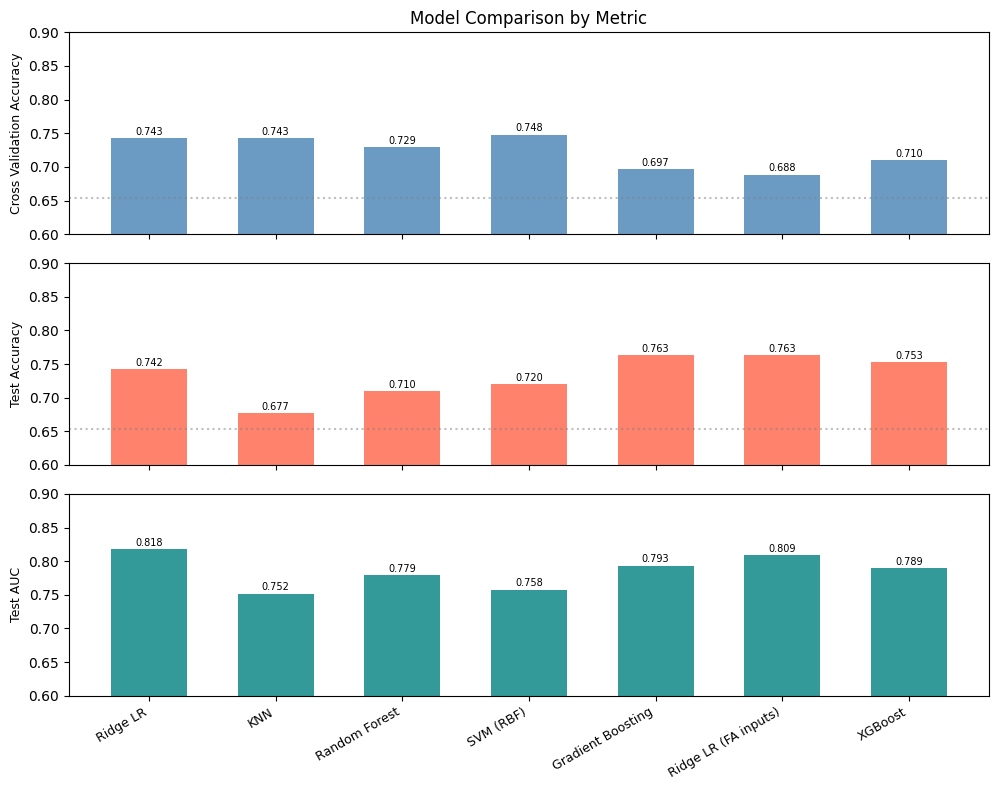

In [ ]:
# models = list(results.keys())
# cv_accs = [results[m]["cv_acc"] for m in models]
# test_accs = [results[m]["test_acc"] for m in models]
# aucs = [results[m]["test_auc"] for m in models]
# x = np.arange(len(models))
# w = 0.25
# fig, ax = plt.subplots(figsize=(10, 5))
# ax.bar(
#     x - w, cv_accs, w, label="Cross Validation Accuracy", color="steelblue", alpha=0.8
# )
# ax.bar(x, test_accs, w, label="Test Accuracy", color="tomato", alpha=0.8)
# ax.bar(x + w, aucs, w, label="Test AUC", color="teal", alpha=0.8)
# ax.set_xticks(x)
# ax.set_xticklabels(models, rotation=30, ha="right", fontsize=9)
# ax.set_ylabel("Score")
# ax.set_title("Model Comparison: Cross Validation Accuracy, Test Accuracy, and AUC")
# ax.legend(loc="lower right")
# ax.set_ylim(0.6, 0.9)
# ax.axhline(0.654, ls=":", color="grey", alpha=0.5, label="Baseline (majority class)")
# ax.legend(loc="upper right", fontsize=8)
# plt.tight_layout()
# savefig("fig_model_comparison_bar")
# plt.show()

# 0.5 baseline for AUC, and 0.654 for accuracy (based on positive cases in data)
baselines = [0.654, 0.654, 0.5]
fig, axes = plt.subplots(3, 1, figsize=(10, 8), sharex=True)

models = list(results.keys())
x = np.arange(len(models))
colours = ["steelblue", "tomato", "teal"]
metrics = [
    ("Cross Validation Accuracy", [results[m]["cv_acc"] for m in models]),
    ("Test Accuracy", [results[m]["test_acc"] for m in models]),
    ("Test AUC", [results[m]["test_auc"] for m in models]),
]

for ax, (label, values), colour, baseline in zip(axes, metrics, colours, baselines):
    bars = ax.bar(x, values, color=colour, alpha=0.8, width=0.6)
    ax.set_ylabel(label, fontsize=9)
    ax.set_ylim(0.6, 0.9)
    ax.axhline(baseline, ls=":", color="grey", alpha=0.5)
    for bar, v in zip(bars, values):
        ax.text(
            bar.get_x() + bar.get_width() / 2,
            v + 0.005,
            f"{v:.3f}",
            ha="center",
            fontsize=7,
        )

axes[-1].set_xticks(x)
axes[-1].set_xticklabels(models, rotation=30, ha="right", fontsize=9)
axes[0].set_title("Model Comparison by Metric")

plt.tight_layout()
savefig("fig_model_comparison_bar")
plt.show()

### Nested CV - looking for bias

In [ ]:
outer_cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=SEED)
inner_cv = StratifiedKFold(n_splits=10, shuffle=True, random_state=SEED)

nested_clf = GridSearchCV(
    LogisticRegression(penalty="l2", solver="lbfgs", max_iter=1000, random_state=SEED),
    {"C": np.logspace(-4, 4, 20)},
    cv=inner_cv,
    scoring="accuracy",
    n_jobs=-1,
)

nested_scores = cross_val_score(
    nested_clf, X_train_scaled, y_train, cv=outer_cv, scoring="accuracy"
)
print(f"Nested CV accuracy: {nested_scores.mean():.3f} ± {nested_scores.std():.3f}")

Nested CV accuracy: 0.732 ± 0.043


### McNemar's test

Statistical test for whether two classifiers' errors are significantly different.

In [ ]:

# Compare Ridge LR vs Gradient Boosting predictions
lr_correct = (y_pred_lr == y_test)
gb_correct = (results["Gradient Boosting"]["y_pred"] == y_test)

# Contingency: both right, LR right/GB wrong, LR wrong/GB right, both wrong
table = pd.crosstab(lr_correct, gb_correct)
print("Contingency table (Ridge LR correct vs GB correct):")
print(table)

result = mcnemar(table.values, exact=True)
print(f"\nMcNemar's test: p = {result.pvalue:.3f}")

Contingency table (Ridge LR correct vs GB correct):
chd    False  True 
chd                
False     17      7
True       5     64

McNemar's test: p = 0.774


In [ ]:
for name in results:
    if name == "Ridge LR":
        continue
    other_correct = results[name]["y_pred"] == y_test
    lr_correct = y_pred_lr == y_test
    table = pd.crosstab(lr_correct, other_correct)
    result = mcnemar(table.values, exact=True)
    print(f"Ridge LR vs {name:25s}: p = {result.pvalue:.3f}")

Ridge LR vs KNN                      : p = 0.146
Ridge LR vs Random Forest            : p = 0.581
Ridge LR vs SVM (RBF)                : p = 0.754
Ridge LR vs Gradient Boosting        : p = 0.774
Ridge LR vs Ridge LR (FA inputs)     : p = 0.815
Ridge LR vs XGBoost                  : p = 1.000


The CV to test gap is as important as the accuracy. A positive gap indicates the model performs worse on unseen data than during training, suggesting overfitting. A negative gap (test better than CV) typically reflects random variation on a small test set rather than genuine superiority.

Ridge LR has a gap of 0.001, indicating near perfect generalisation stability. SVM shows the largest positive gap (0.028), consistent with mild overfitting on 462 samples. Gradient Boosting and Ridge LR with FA inputs both show negative gaps of approximately 0.07, which is suspicious given only 93 test patients.

The nested CV result ($73.2\% \pm 4.3\%$) (mean $\pm$ SD) provides the most honest performance estimate. The $\pm4.3\%$ uncertainty band means that the 2 to 6 percentage point accuracy differences between classifiers fall within sampling noise. 

None of the models are statistically distinguishable from ridge logistic regression. McNemar's test confirms this formally: pairwise comparison of Ridge LR against every alternative yields p values ranging from 0.146 (KNN) to 1.000 (XGBoost), with no model reaching significance at any conventional threshold (not even factoring in potential bonferroni). Ridge LR and XGBoost produce identical error patterns (p = 1.000), while KNN comes closest to a detectable difference but still falls short (p = 0.146).

The choice of best model depends on the intended clinical use:

- For population screening, where the priority is catching as many CHD cases as possible, AUC is the most relevant metric and Ridge LR leads with 0.818. 

- For diagnostic confirmation, where minimising false positives matters, precision is more important and Gradient Boosting's 0.67 precision for CHD class is highest. 

- For stable deployment in a clinical pipeline, the CV to test gap is the deciding factor and Ridge LR's 0.001 gap indicates it will perform most reliably on new patients. Given the small test set and the McNemar result, Ridge LR is preferred on grounds of interpretability, calibration, and generalisation stability rather than a clear accuracy advantage.

In [ ]:

# Compare Ridge LR vs Gradient Boosting predictions
lr_correct = (y_pred_lr == y_test)
gb_correct = (results["Gradient Boosting"]["y_pred"] == y_test)

# Contingency: both right, LR right/GB wrong, LR wrong/GB right, both wrong
table = pd.crosstab(lr_correct, gb_correct)
print("Contingency table (Ridge LR correct vs GB correct):")
print(table)

result = mcnemar(table.values, exact=True)
print(f"\nMcNemar's test: p = {result.pvalue:.3f}")

Contingency table (Ridge LR correct vs GB correct):
chd    False  True 
chd                
False     17      7
True       5     64

McNemar's test: p = 0.774


In [ ]:
for name in results:
    if name == "Ridge LR":
        continue
    other_correct = results[name]["y_pred"] == y_test
    lr_correct = y_pred_lr == y_test
    table = pd.crosstab(lr_correct, other_correct)
    result = mcnemar(table.values, exact=True)
    print(f"Ridge LR vs {name:25s}: p = {result.pvalue:.3f}")

Ridge LR vs KNN                      : p = 0.146
Ridge LR vs Random Forest            : p = 0.581
Ridge LR vs SVM (RBF)                : p = 0.754
Ridge LR vs Gradient Boosting        : p = 0.774
Ridge LR vs Ridge LR (FA inputs)     : p = 0.815
Ridge LR vs XGBoost                  : p = 1.000


### ROC curves

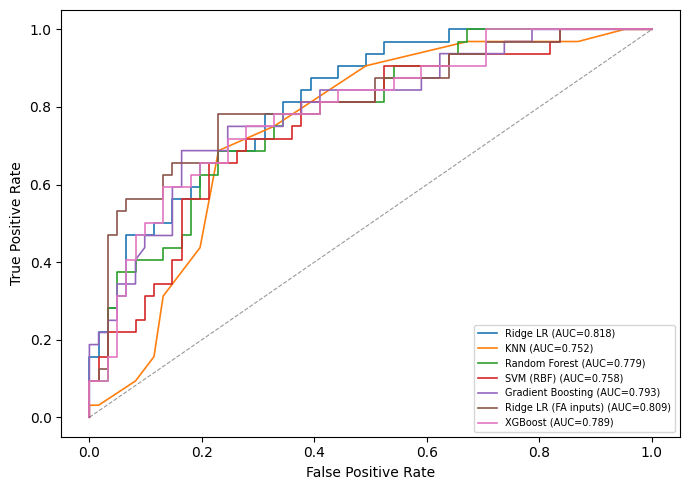

In [ ]:
# ROC curves for all models
fig, ax = plt.subplots(figsize=(7, 5))

for name, r in results.items():
    if r["y_prob"] is not None:
        fpr, tpr, _ = roc_curve(y_test, r["y_prob"])
        ax.plot(fpr, tpr, label=f"{name} (AUC={r['test_auc']:.3f})", linewidth=1.2)

ax.plot([0, 1], [0, 1], "k--", alpha=0.4, linewidth=0.8)
ax.set_xlabel("False Positive Rate")
ax.set_ylabel("True Positive Rate")
# ax.set_title("ROC Curves — All Models")
ax.legend(fontsize=7, loc="lower right")
plt.tight_layout()
savefig("fig_roc_curves-old")
plt.show()

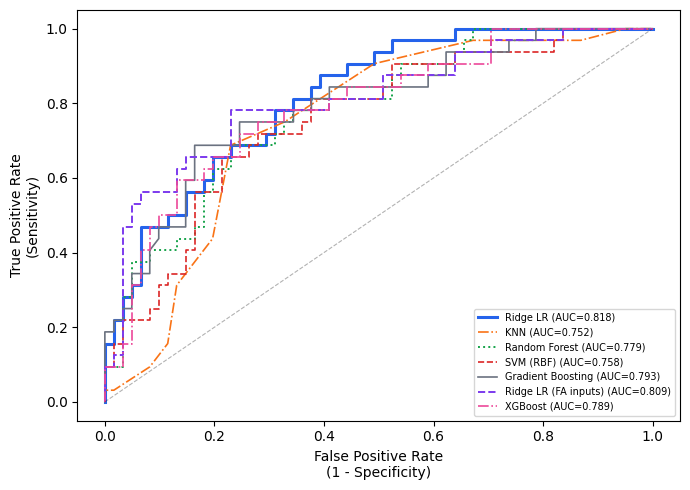

In [ ]:
# improving on above by making more visually distinct
fig, ax = plt.subplots(figsize=(7, 5))

# emphasising Ridge LR
style_map = {
    "Ridge LR":              {"color": "#2563EB", "ls": "-",  "lw": 2.2},  
    "Ridge LR (FA inputs)":  {"color": "#7C3AED", "ls": "--", "lw": 1.4},
    "KNN":                   {"color": "#F97316", "ls": "-.",  "lw": 1.2},
    "Random Forest":         {"color": "#16A34A", "ls": ":",  "lw": 1.4},
    "SVM (RBF)":             {"color": "#DC2626", "ls": "--", "lw": 1.2},
    "Gradient Boosting":     {"color": "#6B7280", "ls": "-",  "lw": 1.2},
    "XGBoost":               {"color": "#EC4899", "ls": "-.", "lw": 1.2},
}

for name, r in results.items():
    if r["y_prob"] is not None:
        fpr, tpr, _ = roc_curve(y_test, r["y_prob"])
        s = style_map.get(name, {"color": "black", "ls": "-", "lw": 1.0})
        ax.plot(fpr, tpr,
                label=f"{name} (AUC={r['test_auc']:.3f})",
                color=s["color"], linestyle=s["ls"], linewidth=s["lw"])

ax.plot([0, 1], [0, 1], "k--", alpha=0.3, linewidth=0.8)
ax.set_xlabel("False Positive Rate\n(1 - Specificity)")
ax.set_ylabel("True Positive Rate\n(Sensitivity)")
ax.legend(fontsize=7, loc="lower right")
plt.tight_layout()
savefig("fig_roc_curves")
plt.show()

### Random forest feature importance

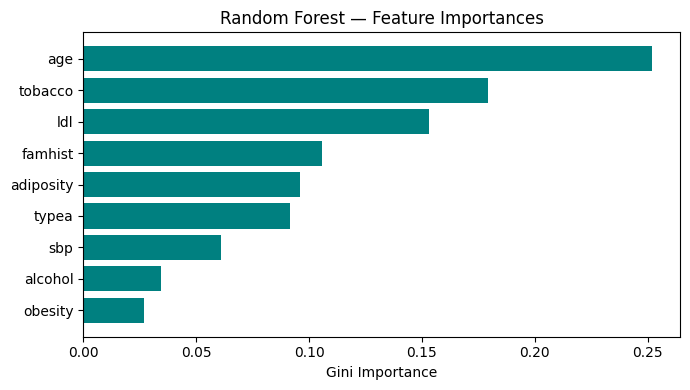

In [ ]:
# RF feature importances 
# which features matter for the best tree model?
rf_model = results["Random Forest"]["model"]
imp_df = pd.DataFrame({
    "Feature": X.columns,
    "Importance": rf_model.feature_importances_
}).sort_values("Importance")

fig, ax = plt.subplots(figsize=(7, 4))
ax.barh(imp_df["Feature"], imp_df["Importance"], color="teal")
ax.set_xlabel("Gini Importance")
ax.set_title("Random Forest — Feature Importances")
plt.tight_layout()
savefig("fig_rf_importances")
plt.show()

Random forest importances confirm the ridge LR findings: age and tobacco dominate. However, RF also assigns meaningful weight to adiposity, unlike ridge LR where it was suppressed by collinearity. 

This difference arises because decision trees handle correlated features differently. At each split, a tree can use either adiposity or obesity interchangeably, so both accumulate importance. Linear models partition credit between them, and the ridge penalty ensures neither receives a disproportionate share.

### SHAP (gradient boosting) to compare with ridge

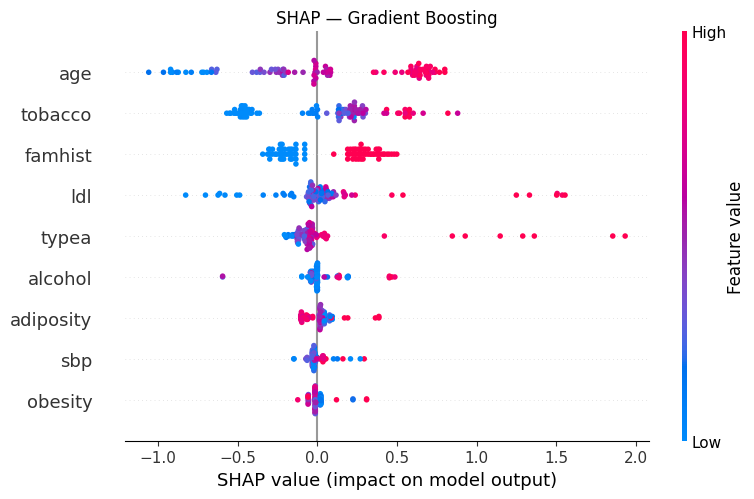

In [ ]:
gb_model = results["Gradient Boosting"]["model"]
explainer_gb = shap.TreeExplainer(gb_model)
shap_values_gb = explainer_gb.shap_values(X_test_scaled)

shap.summary_plot(
    shap_values_gb, X_test_scaled, feature_names=X.columns.tolist(), show=False
)
plt.title("SHAP — Gradient Boosting")
plt.tight_layout()
savefig("fig_shap_gb")
plt.show()

### Best model examination

Best by test accuracy: Gradient Boosting         (0.76300)
Best by test AUC:      Ridge LR                  (0.81800)
Best by test F1 (CHD): Gradient Boosting         (0.64500)


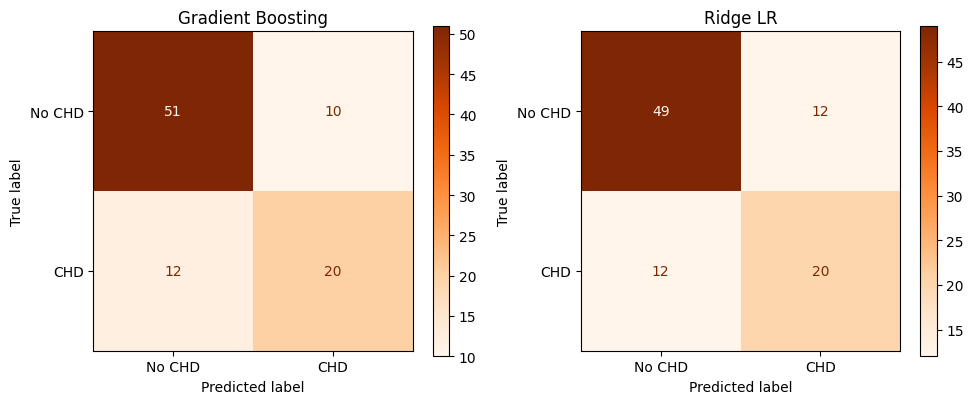

In [ ]:
# Identify best model per metric
best_acc_name = comparison.sort_values("Test Accuracy", ascending=False).iloc[0][
    "Model"
]
best_auc_name = comparison.sort_values("Test AUC", ascending=False).iloc[0]["Model"]
best_f1_name = comparison.sort_values("Test F1 (CHD)", ascending=False).iloc[0]["Model"]

print(
    f"Best by test accuracy: {best_acc_name:25s} ({comparison.set_index('Model').loc[best_acc_name, 'Test Accuracy']:.5f})"
)
print(
    f"Best by test AUC:      {best_auc_name:25s} ({comparison.set_index('Model').loc[best_auc_name, 'Test AUC']:.5f})"
)
print(
    f"Best by test F1 (CHD): {best_f1_name:25s} ({comparison.set_index('Model').loc[best_f1_name, 'Test F1 (CHD)']:.5f})"
)

# Show confusion matrices for distinct winners
winners = dict.fromkeys([best_acc_name, best_auc_name, best_f1_name])
fig, axes = plt.subplots(1, len(winners), figsize=(5 * len(winners), 4))
if len(winners) == 1:
    axes = [axes]
for ax, name in zip(axes, winners):
    ConfusionMatrixDisplay.from_predictions(
        y_test,
        results[name]["y_pred"],
        ax=ax,
        cmap="Oranges",
        display_labels=["No CHD", "CHD"],
    )
    ax.set_title(f"{name}")
plt.tight_layout()
savefig("fig_best_confusion_matrices")
plt.show()

---

## Inference statistics

Inference statistics are meaningful for logistic regression where coefficients have a direct interpretation (log-odds). For RF, SVM, KNN there are no coefficients to test, so p-values don't apply. SHAP and permutation importance already serve that role for the nonlinear models.


In [ ]:
import statsmodels.api as sm

X_with_const = sm.add_constant(X_train_scaled)
logit_model = sm.Logit(y_train, X_with_const).fit()
print(logit_model.summary())

Optimization terminated successfully.
         Current function value: 0.517853
         Iterations 6
                           Logit Regression Results                           
Dep. Variable:                    chd   No. Observations:                  369
Model:                          Logit   Df Residuals:                      359
Method:                           MLE   Df Model:                            9
Date:                Fri, 27 Mar 2026   Pseudo R-squ.:                  0.1977
Time:                        14:43:19   Log-Likelihood:                -191.09
converged:                       True   LL-Null:                       -238.19
Covariance Type:            nonrobust   LLR p-value:                 2.330e-16
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const         -0.8642      0.136     -6.338      0.000      -1.131      -0.597
x1             0.1419      0.

In [ ]:
X_with_const = sm.add_constant(pd.DataFrame(X_train_scaled, columns=X.columns))

# Bootstrap confidence intervals for ridge LR coefficients
from sklearn.utils import resample

n_boot = 1000
boot_coefs = np.zeros((n_boot, X.shape[1]))

for i in range(n_boot):
    X_boot, y_boot = resample(X_train_scaled, y_train, random_state=i, stratify=y_train)
    lr_boot = LogisticRegression(
        penalty="l2", C=best_lr.C, solver="lbfgs", max_iter=1000, random_state=SEED
    )
    lr_boot.fit(X_boot, y_boot)
    boot_coefs[i] = lr_boot.coef_[0]

# 95% percentile intervals
ci_lower = np.percentile(boot_coefs, 2.5, axis=0)
ci_upper = np.percentile(boot_coefs, 97.5, axis=0)

ci_df = pd.DataFrame(
    {
        "Feature": X.columns,
        "Coefficient": best_lr.coef_[0],
        "CI Lower": ci_lower,
        "CI Upper": ci_upper,
        "Significant": [
            "*" if lo * up > 0 else "" for lo, up in zip(ci_lower, ci_upper)
        ],
    }
).sort_values("Coefficient", key=abs, ascending=False)

print(f"Bootstrap 95% CIs ({n_boot} iterations, C={best_lr.C:.3f}):")
print(ci_df.to_string(index=False))

Bootstrap 95% CIs (1000 iterations, C=0.616):
  Feature  Coefficient  CI Lower  CI Upper Significant
      age     0.700631  0.393347  1.063041           *
  famhist     0.433724  0.202350  0.682614           *
      ldl     0.389561  0.143110  0.687152           *
    typea     0.357234  0.119849  0.657637           *
  tobacco     0.314976  0.058209  0.588446           *
      sbp     0.140667 -0.132664  0.410069            
adiposity    -0.099138 -0.522847  0.360542            
  alcohol    -0.045790 -0.286954  0.212330            
  obesity    -0.017416 -0.434483  0.339811            


In [ ]:
# 99% percentile intervals
ci_lower = np.percentile(boot_coefs, 0.5, axis=0)
ci_upper = np.percentile(boot_coefs, 99.5, axis=0)

ci_df = pd.DataFrame(
    {
        "Feature": X.columns,
        "Coefficient": best_lr.coef_[0],
        "CI Lower": ci_lower,
        "CI Upper": ci_upper,
        "Significant": [
            "*" if lo * up > 0 else "" for lo, up in zip(ci_lower, ci_upper)
        ],
    }
).sort_values("Coefficient", key=abs, ascending=False)

print(f"Bootstrap 99% CIs ({n_boot} iterations, C={best_lr.C:.3f}):")
print(ci_df.to_string(index=False))

Bootstrap 99% CIs (1000 iterations, C=0.616):
  Feature  Coefficient  CI Lower  CI Upper Significant
      age     0.700631  0.289933  1.136835           *
  famhist     0.433724  0.133197  0.750913           *
      ldl     0.389561  0.016208  0.791167           *
    typea     0.357234  0.055800  0.732567           *
  tobacco     0.314976 -0.032148  0.704183            
      sbp     0.140667 -0.206365  0.486287            
adiposity    -0.099138 -0.622739  0.511814            
  alcohol    -0.045790 -0.353364  0.316617            
  obesity    -0.017416 -0.586530  0.404714            


Bootstrap confidence intervals provide inference for the ridge penalised model, which `statsmodels` cannot fit directly. At 95% confidence, five features have intervals excluding zero: age, family history, LDL, Type A behaviour, and tobacco. At 99%, tobacco loses significance (CI lower bound crosses zero at -0.032), leaving four features robust at the stricter threshold. Blood pressure, adiposity, obesity, and alcohol are not significant at either level, with wide intervals spanning both positive and negative values.

This aligns with other methods applied in this analysis. The `statsmodels` unpenalised logistic regression identifies the same five significant predictors at 95% ($p < 0.05$ for tobacco, LDL, famhist, typea, age) and the same four at 99% (tobacco's $p = 0.016$ would not survive Bonferroni correction for 9 tests). 

The convergence across ridge bootstrap CIs, unpenalised Wald tests, SHAP values, permutation importance, elastic net feature selection, and random forest importances provides strong evidence that the feature importance ranking is a genuine property of the data rather than an artefact of any single method.

In [ ]:
import sys
!"{sys.executable}" -m pip freeze > requirements.txt